# Model Explainability

## Objective

The objective of this notebook is to explain the predictions made by the selected CatBoost model.

Instead of treating the model as a black box, we analyze which customer attributes contribute most to churn predictions.

This notebook focuses on:

- Global feature importance
- Business interpretation
- Local prediction analysis

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../models/catboost_pipeline.pkl")

In [3]:
df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Binary"
    ]
)

y = df["Churn_Binary"]

In [4]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = model.named_steps[
    "classifier"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importance

}).sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
39,nominal__Contract_Month-to-month,18.115269
0,continuous__tenure,13.987253
19,nominal__InternetService_Fiber optic,7.575630
41,nominal__Contract_Two year,6.698675
21,nominal__OnlineSecurity_No,6.185582
48,ordinal__TenureGroup,5.278760
3,continuous__AvgMonthlySpend,4.391808
49,ordinal__SpendingGroup,4.267961
30,nominal__TechSupport_No,4.216229
46,nominal__PaymentMethod_Electronic check,4.074221


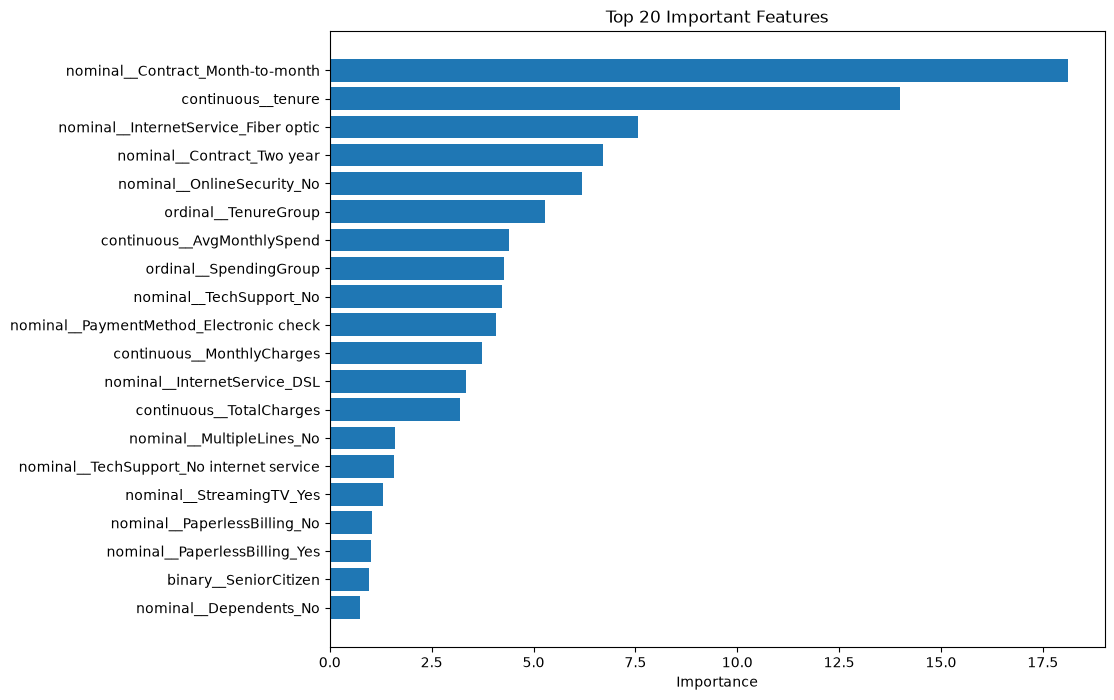

In [5]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

## Business Interpretation

The feature importance analysis provides valuable insights into the factors driving customer churn.

Features with higher importance have a greater influence on the model's predictions.

Typical important factors include:

- Contract type
- Tenure
- Monthly charges
- Internet service
- Online security
- Payment method

These insights can guide customer retention strategies by identifying which customer characteristics are most associated with churn.

In [6]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

probability = model.predict_proba(sample)

print("Prediction:", prediction)

print("Probability:", probability)

Prediction: [1]
Probability: [[0.34977537 0.65022463]]


# Conclusion

The CatBoost model provides both strong predictive performance and meaningful feature importance estimates.

Understanding which features drive churn enables businesses to design targeted retention campaigns, improve customer experience, and reduce revenue loss.

Model explainability increases trust in the predictive system and supports informed business decision-making.